In [1]:
from cytetype import CyteType
import scanpy as sc

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
adata = sc.read_h5ad('../../data/talbot_xenium_tumor.h5ad')

In [3]:
adata.obs.genotype

output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaachibf-1      Pdl1_wt
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaadbpmc-1      Pdl1_wt
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaagejpm-1      Pdl1_wt
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaagiphc-1      Pdl1_wt
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaahpgfk-1      Pdl1_wt
                                                                      ...   
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oikfjlfk-1    Pdl1_cre
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilbhfce-1    Pdl1_cre
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilfjaec-1    Pdl1_cre
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilfkjkg-1    Pdl1_cre
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilnplad-1    Pdl1_cre
Name: genotype, Length: 207468, dtype: category
Categories (5, object): ['Oprl1_cre', 'Oprl1_wt', 'Pdl1_cre', 'Pdl1_wt', 'c57']

In [4]:
adata.var = adata.var.reset_index()

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [5]:
adata.var['gene_symbols'] = adata.var['index']

In [6]:
adata.var['gene_symbols']

0         A1cf
1          A2m
2         Aatf
3        Abca1
4       Abca13
         ...  
5001    Zswim9
5002      Zup1
5003       Zyx
5004     Zzef1
5005         a
Name: gene_symbols, Length: 5006, dtype: object

In [7]:
adata.var = adata.var.set_index('index')

In [8]:
study_context = (
    "Mouse melanoma tissue profiled with the Xenium platform to resolve the spatial organization of tumor, stromal, "
    "and immune cell populations. The dataset includes multiple genotypes—Oprl1_cre, Oprl1_wt, Pdl1_cre, Pdl1_wt, "
    "and C57—representing genetic backgrounds relevant to immune checkpoint regulation and tumor–immune interactions. "
    "This study enables spatially resolved analysis of gene expression, cell–cell communication, and microenvironmental "
    "differences across melanoma genotypes."
)

In [9]:
# ------ CyteType ------
annotator = CyteType(adata, group_key="leiden_4")
adata = annotator.run(
    study_context=study_context,
)


Using coordinates from 'X_umap' for visualization.
Calculating expression percentages.
Extracting marker genes.
Preparing visualization data with sampling.
Sampled 1000 cells from group '3' (originally 7946 cells)
Sampled 1000 cells from group '40' (originally 2037 cells)
Sampled 1000 cells from group '38' (originally 2061 cells)
Sampled 1000 cells from group '26' (originally 2624 cells)
Sampled 1000 cells from group '13' (originally 5087 cells)
Sampled 1000 cells from group '47' (originally 1697 cells)
Sampled 1000 cells from group '11' (originally 5170 cells)
Sampled 1000 cells from group '2' (originally 7960 cells)
Sampled 1000 cells from group '31' (originally 2324 cells)
Sampled 1000 cells from group '23' (originally 3866 cells)
Sampled 1000 cells from group '51' (originally 1386 cells)
Sampled 1000 cells from group '45' (originally 1755 cells)
Sampled 1000 cells from group '49' (originally 1668 cells)
Sampled 1000 cells from group '41' (originally 1824 cells)
Sampled 1000 cells f

In [10]:
adata.obs['cytetype_annotation_leiden_4']

output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaachibf-1                              Epithelial Cell (Trp63+)
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaadbpmc-1                              Epithelial Cell (Trp63+)
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaagejpm-1                              Epithelial Cell (Epcam+)
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaagiphc-1                              Epithelial Cell (Trp63+)
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaahpgfk-1                              Epithelial Cell (Trp63+)
                                                                                          ...                        
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oikfjlfk-1                  M2-like Tumor-Associated Macrophage
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilbhfce-1                               Thymic Epithelial Cell
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oi

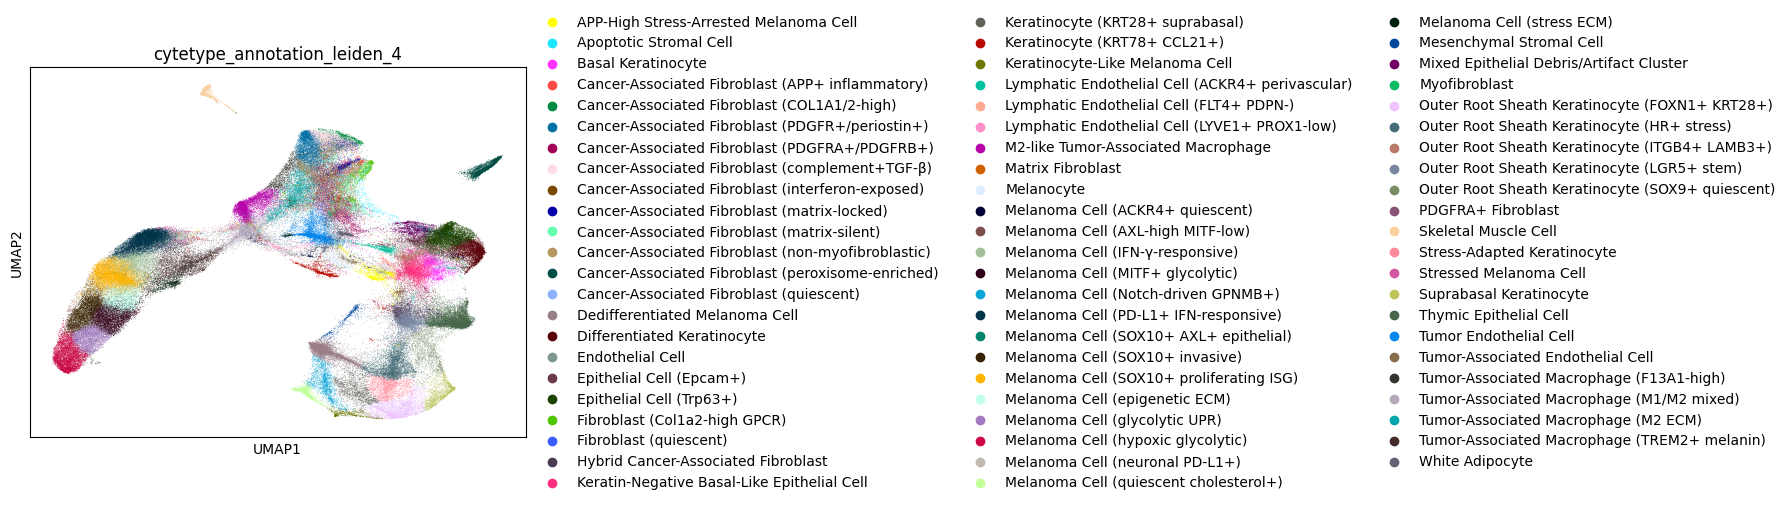

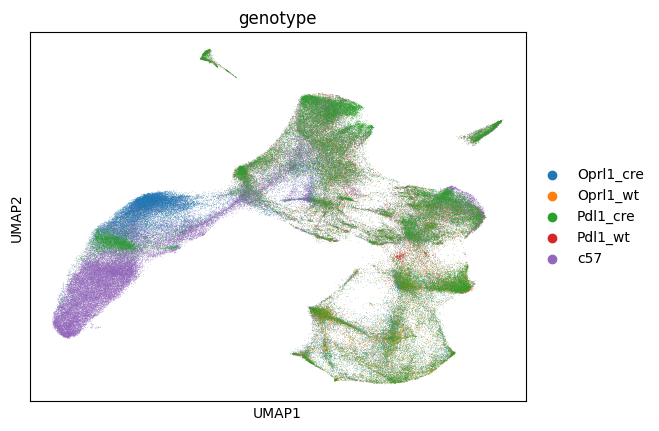

In [20]:
sc.pl.umap(adata, color = 'cytetype_annotation_leiden_4')
sc.pl.umap(adata, color = 'genotype')

In [12]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
import warnings
warnings.filterwarnings("ignore")


def plot_spatial_compact_fast(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=8,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,            # dict {cat:"#hex"} or list
    rasterized=True,         # big speedup for vectors/PDFs
    invert_y=True,           # match Scanpy orientation
    dpi=120,                 # lower dpi → faster
):
    # ----- 0) Preconditions -----
    if "spatial" not in ad.obsm:
        raise ValueError("ad.obsm['spatial'] is required.")

    coords = np.asarray(ad.obsm["spatial"])[:, :2]
    cats = ad.obs[color].astype("category")
    cat_names = cats.cat.categories
    cat_codes = cats.cat.codes.to_numpy()  # -1 for NaN

    # ----- 1) Build shared palette (RGBA array) -----
    if isinstance(palette, dict):
        col_list = [palette[c] for c in cat_names]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cat_names):
            raise ValueError("Palette shorter than number of categories.")
        col_list = list(palette)[:len(cat_names)]
    elif f"{color}_colors" in ad.uns:
        col_list = list(ad.uns[f"{color}_colors"])
        if len(col_list) != len(cat_names):
            raise ValueError(f"{color}_colors length != categories.")
    else:
        base = getattr(getattr(__import__("scanpy").pl.palettes, "default_64", []), "__iter__", None)
        base = list(__import__("scanpy").pl.palettes.default_64
                    if hasattr(__import__("scanpy").pl.palettes, "default_64")
                    else __import__("scanpy").pl.palettes.default_102)
        reps = int(np.ceil(len(cat_names) / len(base)))
        col_list = (base * reps)[:len(cat_names)]

    # store for consistency elsewhere
    ad.uns[f"{color}_colors"] = col_list

    # convert to RGBA float array for fast indexing
    rgba = np.array([mcolors.to_rgba(c) for c in col_list], dtype=float)
    # map codes -> rgba; handle -1 (NaN) as transparent
    colors_arr = np.empty((cat_codes.size, 4), dtype=float)
    colors_arr[cat_codes >= 0] = rgba[cat_codes[cat_codes >= 0]]
    colors_arr[cat_codes < 0] = (0, 0, 0, 0)

    # ----- 2) Precompute group indices (no per-iteration masks) -----
    gvals = ad.obs[groupby].astype(str).to_numpy()
    uniq_groups, gcodes = np.unique(gvals, return_inverse=True)
    # list of index arrays per group
    group_indices = [np.flatnonzero(gcodes == gi) for gi in range(len(uniq_groups))]

    # ----- 3) Figure layout -----
    n = len(uniq_groups)
    rows = int(np.ceil(n / cols))
    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width

    plt.ioff()  # speed: disable interactive redraws
    fig = plt.figure(figsize=(fig_w, height), dpi=dpi, constrained_layout=False)
    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # ----- 4) Panels (fast scatter) -----
    for i, sid in enumerate(uniq_groups):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        idx = group_indices[i]
        if idx.size:
            xy = coords[idx]
            # note: turn off edgecolor & use rasterized for speed
            sca = ax.scatter(
                xy[:, 0], xy[:, 1],
                c=colors_arr[idx],
                s=spot_size,
                marker='o',
                linewidths=0,
                rasterized=rasterized
            )
        ax.set_title(str(sid), fontsize=6, pad=2)
        ax.set_aspect("equal")
        if invert_y:
            ax.invert_yaxis()
        ax.set_axis_off()

    # blank unused
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # ----- 5) Legend (single, shared) -----
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=col_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cat_names)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.ion()  # ✅ correct
    plt.show()

Plotting cytetype_annotation_leiden_4 …


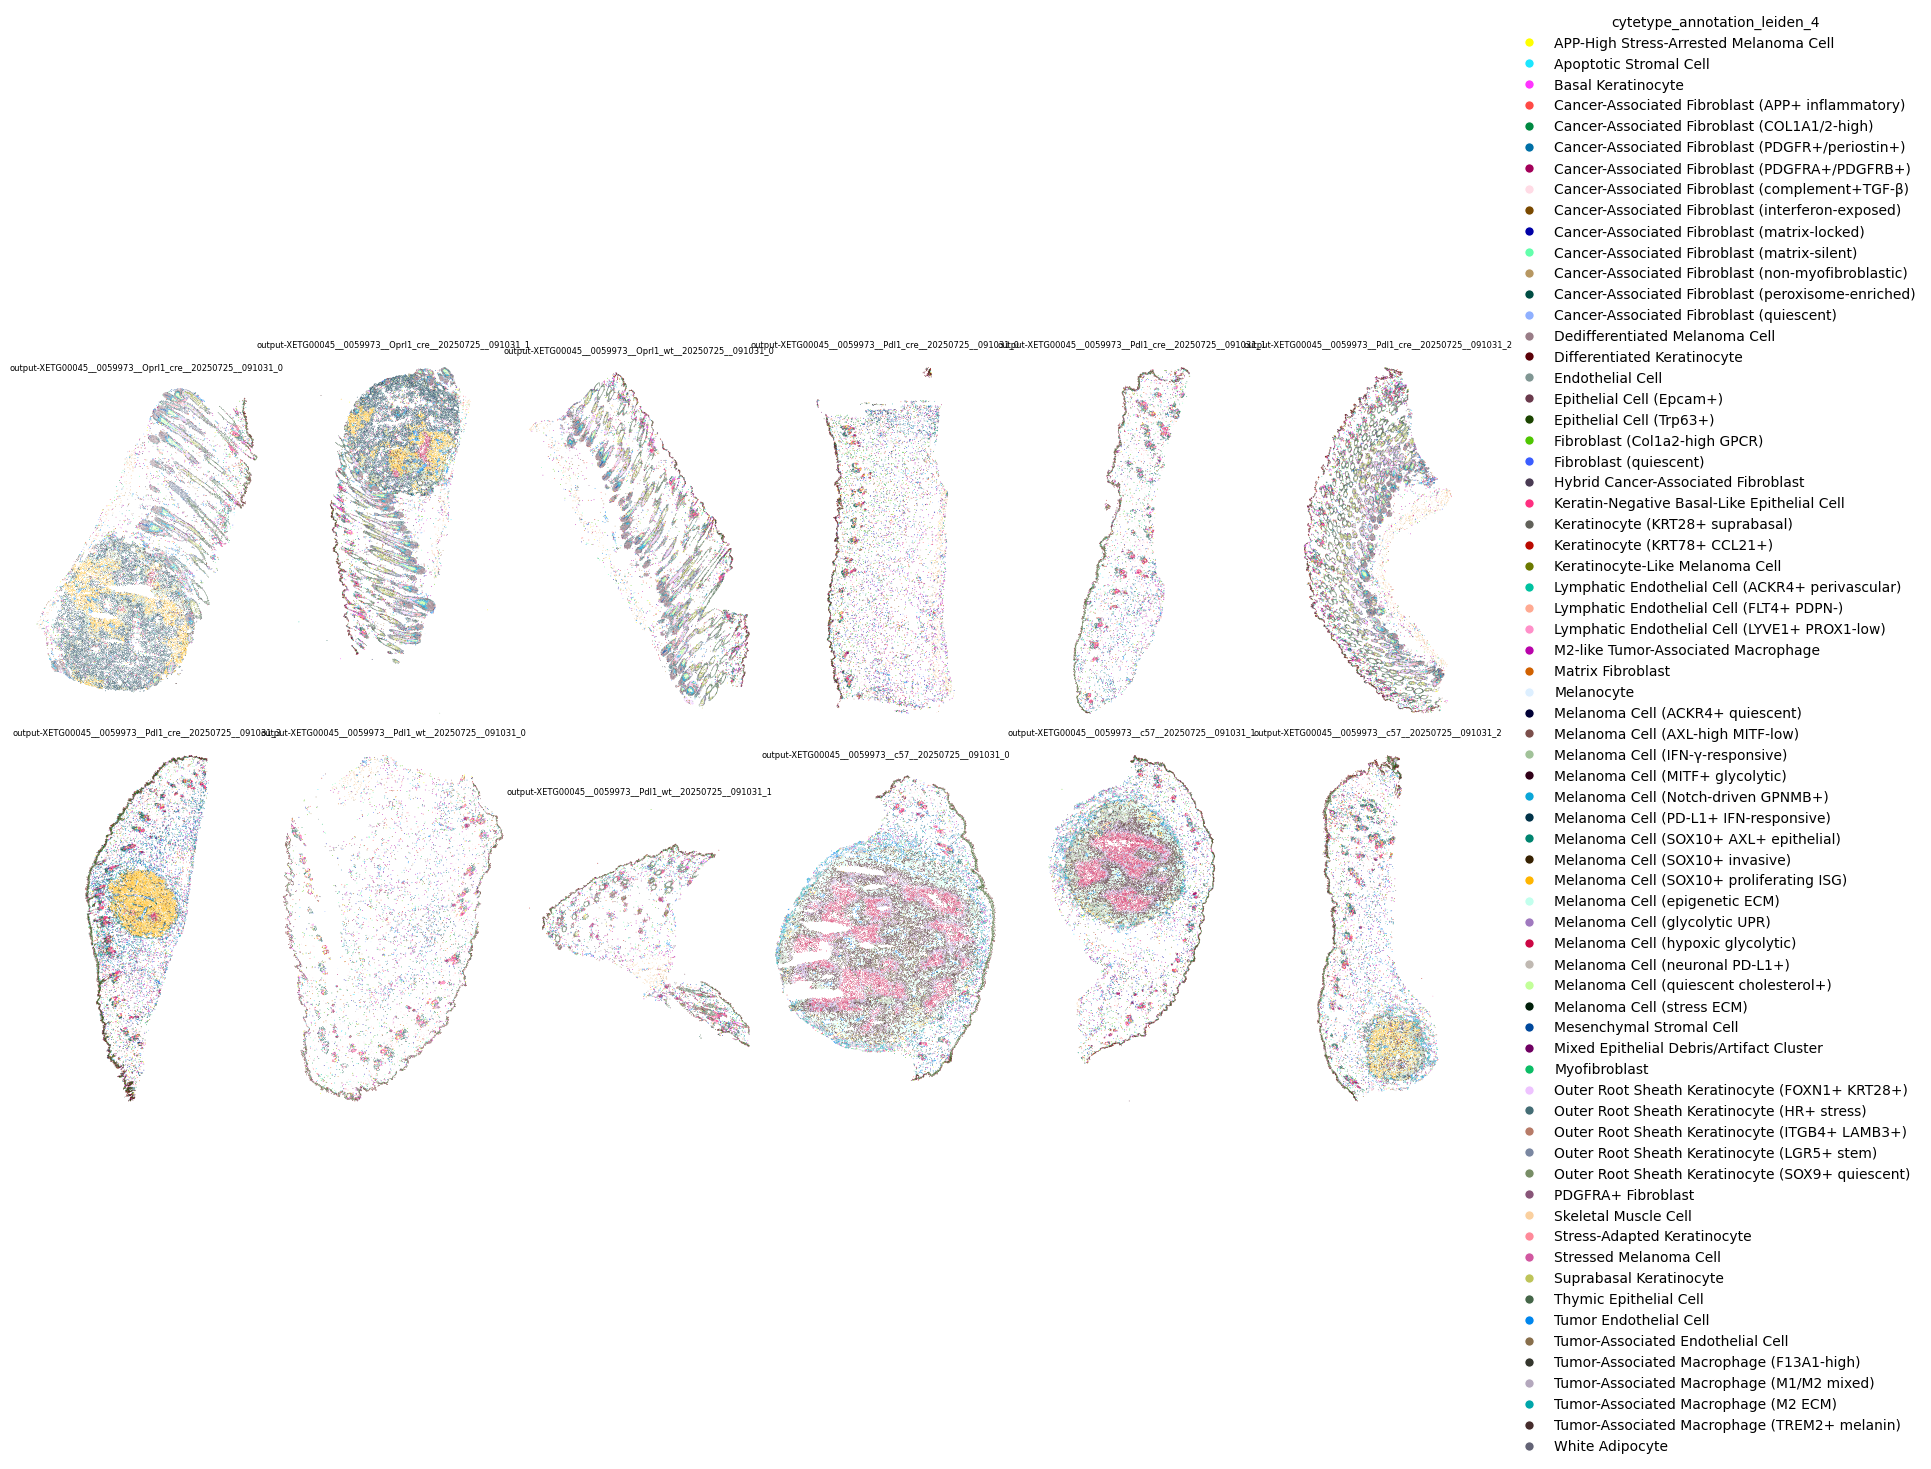

In [13]:
for domain in ['cytetype_annotation_leiden_4']:
    if domain in adata.obs.columns:
        print(f"Plotting {domain} …")
        plot_spatial_compact_fast(
            adata,
            color=domain,
            groupby="sample_id",
            spot_size=0.3,
            cols=6,
            height=8,
            legend_col_width=1.0,
            rasterized=True,   # big speedup for large data
            dpi=100             # lower = faster preview
        )
    else:
        print(f"Skipping {domain} — not in adata.obs")

In [14]:
df = adata.obs[["cytetype_annotation_leiden_4", "genotype"]].copy()
df["CellType"] = df["cytetype_annotation_leiden_4"]

counts = (
    df.groupby(["genotype", "CellType"])
      .size()
      .reset_index(name="Count")
)
counts["Proportion"] = (
    counts.groupby(["genotype"])["Count"]
    .transform(lambda x: x / x.sum())
)



In [15]:
import seaborn as sns

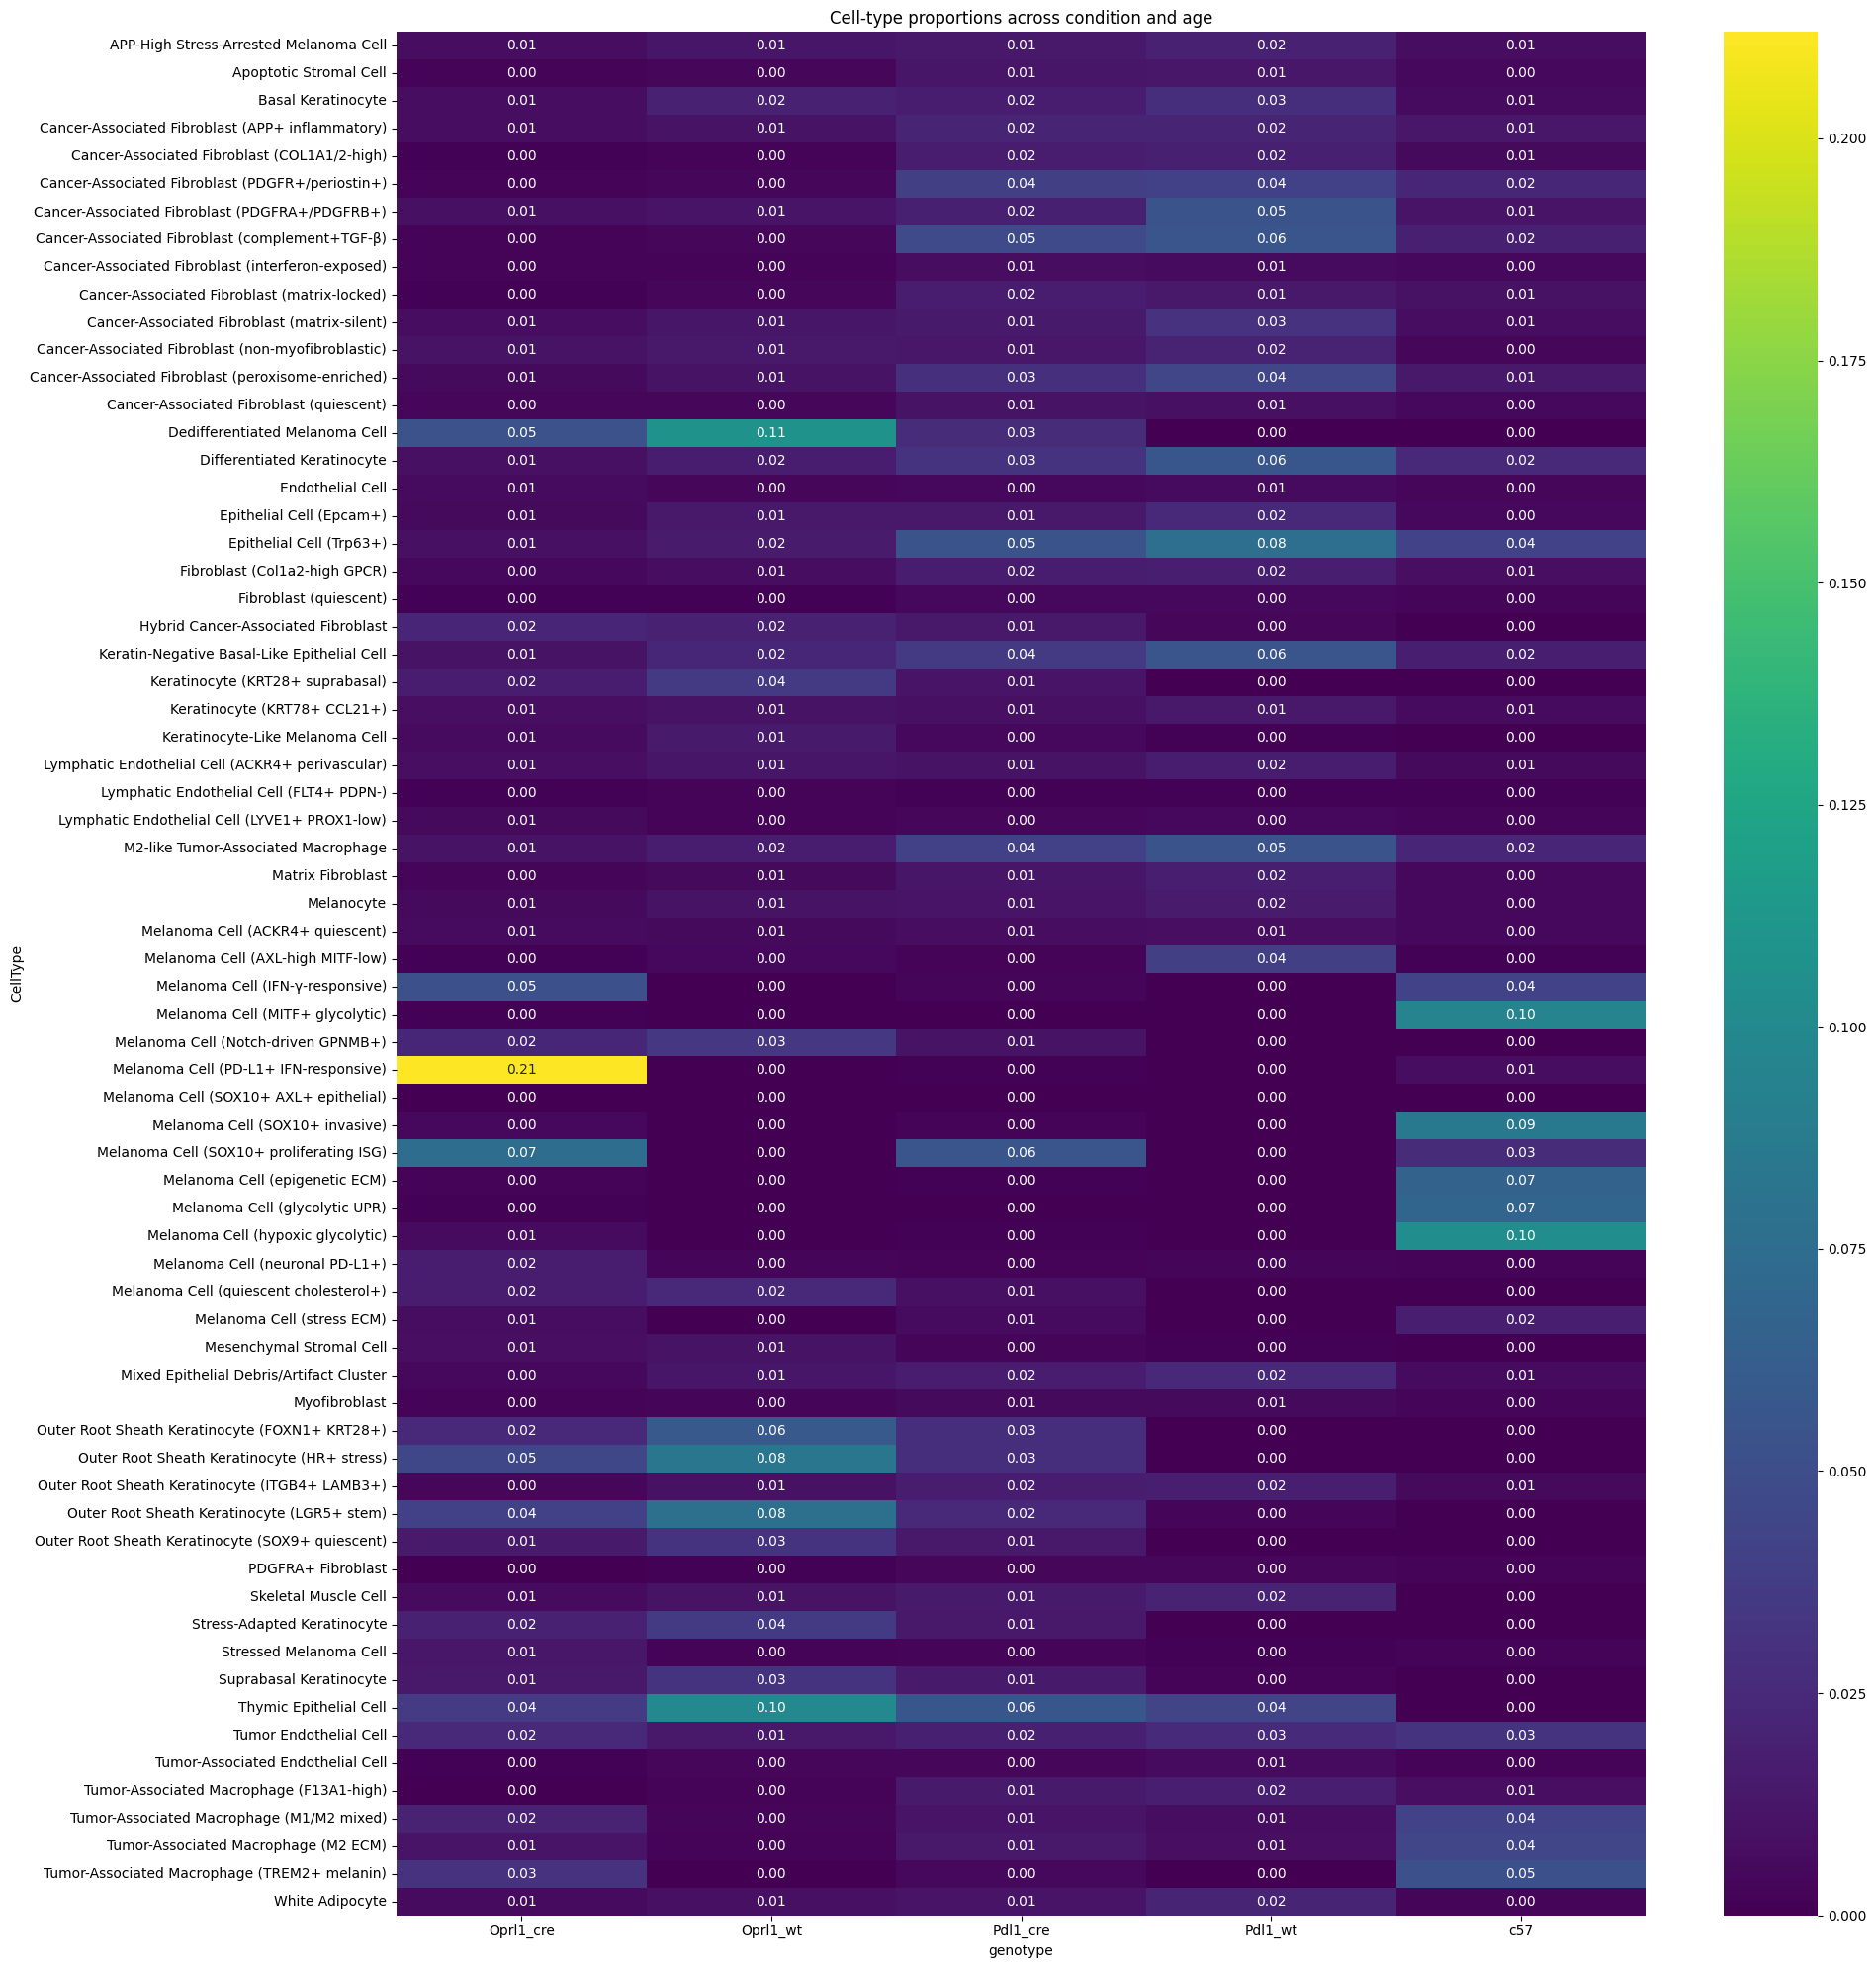

In [16]:
pivot = (
    counts.pivot_table(
        index="CellType", columns=["genotype"],
        values="Proportion", fill_value=0
    )
)

plt.figure(figsize=(20, 20))
sns.heatmap(pivot, cmap="viridis", annot=True, fmt=".2f")
plt.title("Cell-type proportions across condition and age")
plt.tight_layout()
plt.show()

In [17]:
adata.write('../../data/talbot_xenium_tumor_annotated.h5ad')